# Task 2: Fully Convolutional Network (FCN)

Implement an FCN for semantic segmentation, train it on a small dataset, and analyze how architectural and training choices affect performance.

**Instructions:**

**Dataset**:
- Use a subset of Pascal VOC, COCO, or a small custom dataset (10–20 images for quick runs).
- Split into train/test.
- Preprocess (resize, normalize, and convert masks to class indices).
**Model Implementation**:
- Implement FCN-32s, FCN-16s, or FCN-8s variants.
- Use pretrained ResNet/VGG (remove final FC layers) as a backbone
- Upsampling Method: 1) transpose convolution vs 2) bilinear interpolation.
**Training**
- Loss: CrossEntropyLoss
- Optimizer: Adam or SGD
- Metrics: Mean IoU, pixel accuracy
- Train for 20 epochs (or until convergence).
- Log training curves.

**Deliverable:**

- Jupyter notebook with clear code and comments.
- Visualization of segmentation results (min. 3 test images).
- Table comparing transpose convolution vs bilinear interpolation.
- Summarize with visuals and short analysis.

In [18]:
import torch, torch.nn as nn, torch.nn.functional as F
import pandas as pd
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision
from torchvision import transforms
import numpy as np, cv2, matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IMG_SIZE = 128; NUM_CLASSES = 2; BATCH_SIZE = 2
print("Using device:", device)

Using device: cuda


### Dataset
> https://www.kaggle.com/datasets/gopalbhattrai/pascal-voc-2012-dataset

In [22]:
class SimpleSegDataset(Dataset):
    def __init__(self, image_dir, mask_dir, img_size=128):
        self.image_dir = Path(image_dir)
        self.mask_dir = Path(mask_dir)
        self.img_size = img_size

        img_paths = sorted(list(self.image_dir.glob("*")))
        mask_paths = sorted(list(self.mask_dir.glob("*")))

        img_stems = {p.stem for p in img_paths}
        mask_stems = {p.stem for p in mask_paths}
        common = sorted(list(img_stems & mask_stems))

        self.image_paths = [self.image_dir / f"{s}.jpg" for s in common]
        self.mask_paths  = [self.mask_dir / f"{s}.png" for s in common]

        assert len(self.image_paths) == len(self.mask_paths), "Image/mask count mismatch"
        print(f"Matched pairs: {len(self.image_paths)}")

        self.img_transform = transforms.Compose([transforms.Resize((img_size, img_size)),transforms.ToTensor()])
        self.mask_transform = transforms.Compose([transforms.Resize((img_size, img_size), interpolation=transforms.InterpolationMode.NEAREST)])

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = plt.imread(str(self.image_paths[idx]))
        mask = Image.open(str(self.mask_paths[idx])).convert("P") 
        mask = self.mask_transform(mask)
        mask = np.array(mask, dtype=np.int64)

        img = transforms.functional.to_pil_image((img * 255).astype(np.uint8)
                                                 if img.max() <= 1 else img.astype(np.uint8))
        mask = transforms.functional.to_pil_image((mask * 255).astype(np.uint8)
                                                  if mask.max() <= 1 else mask.astype(np.uint8))

        img = self.img_transform(img)
        mask = self.mask_transform(mask)
        mask = torch.from_numpy(np.array(mask) > 0).long()

        return img, mask

In [23]:
images_dir = "data/task2/images/JPEGImages"
masks_dir  = "data/task2/masks/SegmentationClass"

full_dataset = SimpleSegDataset(images_dir, masks_dir, IMG_SIZE)
print("Total samples in full_dataset:", len(full_dataset))

Matched pairs: 2913
Total samples in full_dataset: 2913


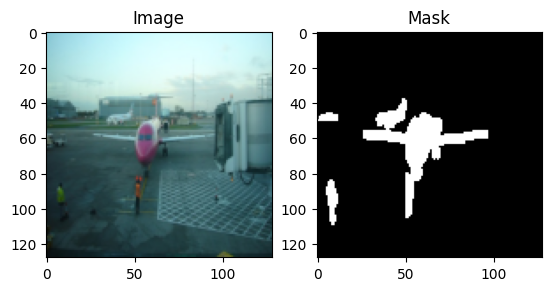

In [24]:
img, mask = full_dataset[0]
plt.subplot(1,2,1)
plt.imshow(img.permute(1,2,0))
plt.title("Image")
plt.subplot(1,2,2)
plt.imshow(mask, cmap="gray")
plt.title("Mask")
plt.show()

### Create Train / Validation Dataloaders

In [25]:
n_total = len(full_dataset)
n_train = max(1, int(0.8 * n_total))
n_val   = n_total - n_train

train_ds, val_ds = random_split(full_dataset, [n_train, n_val])

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

print("Train samples:", len(train_ds))
print("Val samples  :", len(val_ds))

Train samples: 2330
Val samples  : 583


### Model Implementation (FCN)

In [26]:
def make_backbone():
    resnet = torchvision.models.resnet18(weights=torchvision.models.ResNet18_Weights.DEFAULT)
    backbone = nn.Sequential(*list(resnet.children())[:-2])
    return backbone

class FCN_Transpose(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        self.backbone  = make_backbone()
        self.classifier = nn.Conv2d(512, num_classes, kernel_size=1)
        self.up = nn.ConvTranspose2d(num_classes, num_classes,kernel_size=32, stride=32, bias=False)

    def forward(self, x):
        h, w = x.shape[2], x.shape[3]
        x = self.backbone(x)
        x = self.classifier(x)
        x = self.up(x)
        x = F.interpolate(x, size=(h, w), mode="bilinear", align_corners=False)
        return x

class FCN_Bilinear(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        self.backbone  = make_backbone()
        self.classifier = nn.Conv2d(512, num_classes, kernel_size=1)

    def forward(self, x):
        h, w = x.shape[2], x.shape[3]
        x = self.backbone(x)
        x = self.classifier(x)
        x = F.interpolate(x, size=(h, w), mode="bilinear", align_corners=False)
        return x

### Metrics: Pixel Accuracy & Mean IoU

In [27]:
def pixel_accuracy(pred, target):
    correct = (pred == target).sum().item()
    total   = target.numel()
    return correct / total

def mean_iou(pred, target, num_classes=2):
    pred = pred.view(-1)
    target = target.view(-1)
    ious = []
    for cls in range(num_classes):
        pred_i   = (pred == cls)
        target_i = (target == cls)
        inter = (pred_i & target_i).sum().item()
        union = (pred_i | target_i).sum().item()
        if union == 0:
            continue
        ious.append(inter / union)
    return float(np.mean(ious)) if ious else 0.0

### Training Loop

In [28]:
def train_segmentation(model, train_loader, val_loader,num_epochs=20, lr=1e-4, num_classes=2, title="Model"):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history = {"train_loss": [], "val_loss": [],"val_acc": [], "val_miou": []}

    for epoch in range(num_epochs):
        # train
        model.train()
        train_loss = 0.0
        for imgs, masks in train_loader:
            imgs  = imgs.to(device)
            masks = masks.to(device)

            logits = model(imgs)       
            loss   = criterion(logits, masks)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        train_loss /= len(train_loader)

        # validate
        model.eval()
        val_loss = 0.0
        val_acc  = 0.0
        val_miou = 0.0
        with torch.no_grad():
            for imgs, masks in val_loader:
                imgs  = imgs.to(device)
                masks = masks.to(device)

                logits = model(imgs)
                loss   = criterion(logits, masks)
                val_loss += loss.item()

                preds = torch.argmax(logits, dim=1)
                val_acc  += pixel_accuracy(preds, masks)
                val_miou += mean_iou(preds.cpu(), masks.cpu(), num_classes)

        val_loss /= len(val_loader)
        val_acc  /= len(val_loader)
        val_miou /= len(val_loader)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["val_miou"].append(val_miou)

        print(f"[{title}] Epoch {epoch+1}/{num_epochs} "
              f"train={train_loss:.3f} val={val_loss:.3f} "
              f"acc={val_acc:.3f} mIoU={val_miou:.3f}")

    return model, history

### Train Models

In [29]:
EPOCHS = 50

print("Training FCN_Transpose >>>")
model_transpose = FCN_Transpose(num_classes=NUM_CLASSES)
model_transpose, hist_transpose = train_segmentation(model_transpose, train_loader, val_loader,num_epochs=EPOCHS, lr=1e-4, num_classes=NUM_CLASSES,title="Transpose")

print("\nTraining FCN_Bilinear >>>")
model_bilinear = FCN_Bilinear(num_classes=NUM_CLASSES)
model_bilinear, hist_bilinear = train_segmentation(model_bilinear, train_loader, val_loader,num_epochs=EPOCHS, lr=1e-4, num_classes=NUM_CLASSES,title="Bilinear")

Training FCN_Transpose >>>
[Transpose] Epoch 1/50 train=0.503 val=0.407 acc=0.811 mIoU=0.595
[Transpose] Epoch 2/50 train=0.419 val=0.399 acc=0.813 mIoU=0.606
[Transpose] Epoch 3/50 train=0.368 val=0.414 acc=0.806 mIoU=0.601
[Transpose] Epoch 4/50 train=0.331 val=0.395 acc=0.813 mIoU=0.620
[Transpose] Epoch 5/50 train=0.295 val=0.401 acc=0.815 mIoU=0.621
[Transpose] Epoch 6/50 train=0.275 val=0.431 acc=0.809 mIoU=0.617
[Transpose] Epoch 7/50 train=0.263 val=0.401 acc=0.825 mIoU=0.636
[Transpose] Epoch 8/50 train=0.246 val=0.408 acc=0.821 mIoU=0.632
[Transpose] Epoch 9/50 train=0.248 val=0.415 acc=0.819 mIoU=0.631
[Transpose] Epoch 10/50 train=0.235 val=0.422 acc=0.822 mIoU=0.633
[Transpose] Epoch 11/50 train=0.236 val=0.434 acc=0.820 mIoU=0.628
[Transpose] Epoch 12/50 train=0.229 val=0.497 acc=0.800 mIoU=0.598
[Transpose] Epoch 13/50 train=0.221 val=0.450 acc=0.824 mIoU=0.632
[Transpose] Epoch 14/50 train=0.221 val=0.432 acc=0.818 mIoU=0.624
[Transpose] Epoch 15/50 train=0.226 val=0.45

### Plot Training Curves

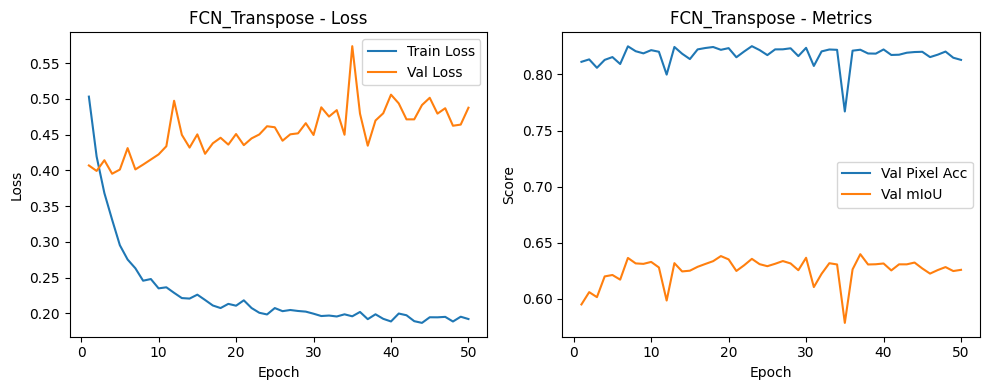

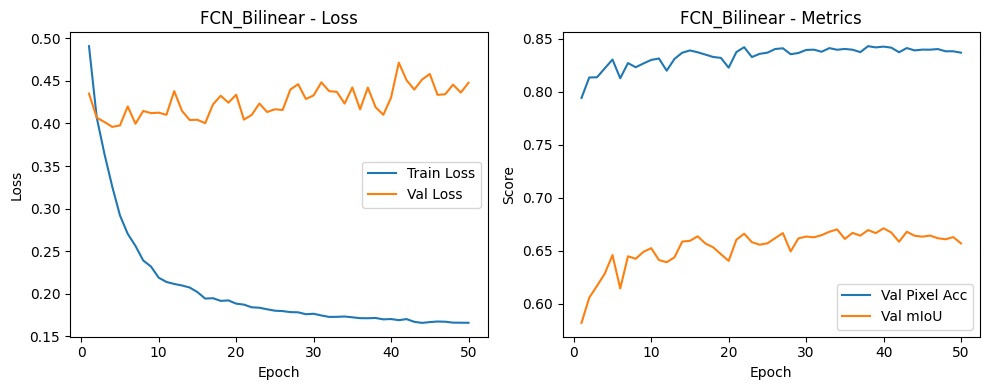

In [30]:
def plot_history(history, title="Model"):
    epochs = range(1, len(history["train_loss"]) + 1)
    plt.figure(figsize=(10,4))

    plt.subplot(1,2,1)
    plt.plot(epochs, history["train_loss"], label="Train Loss")
    plt.plot(epochs, history["val_loss"], label="Val Loss")
    plt.xlabel("Epoch"); plt.ylabel("Loss")
    plt.title(f"{title} - Loss")
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(epochs, history["val_acc"],  label="Val Pixel Acc")
    plt.plot(epochs, history["val_miou"], label="Val mIoU")
    plt.xlabel("Epoch"); plt.ylabel("Score")
    plt.title(f"{title} - Metrics")
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_history(hist_transpose, "FCN_Transpose")
plot_history(hist_bilinear, "FCN_Bilinear")

FCN_Transpose predictions:


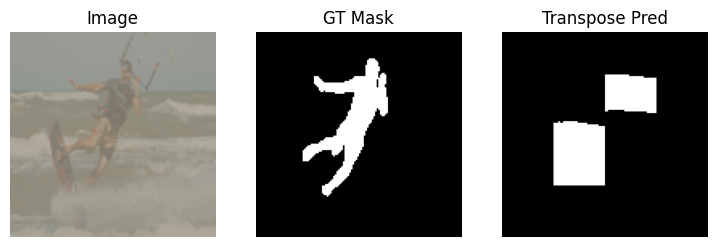

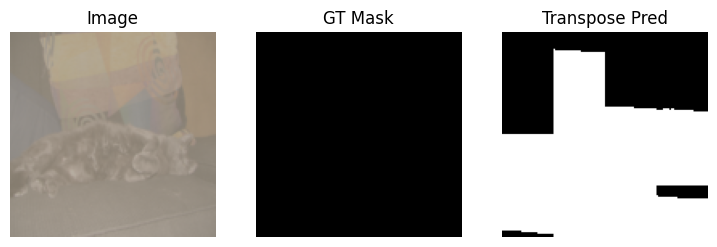

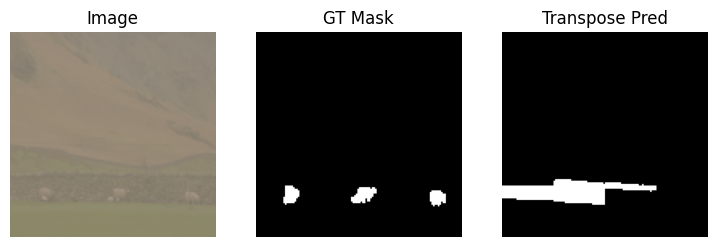

----------------------------------------------------------------------------------------------------
FCN_Bilinear predictions:


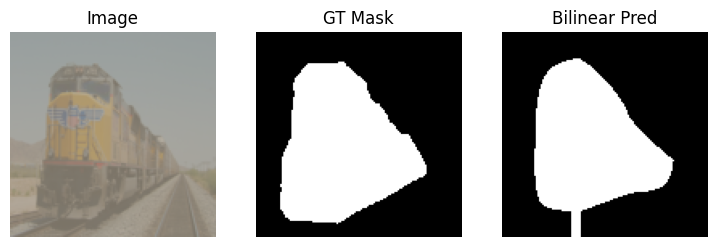

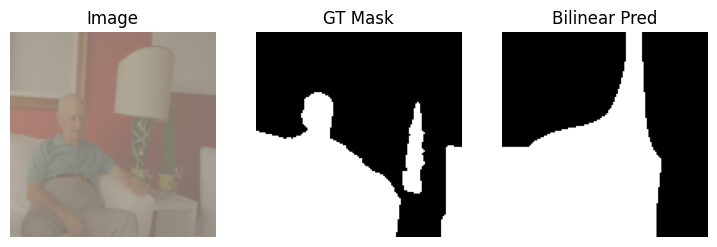

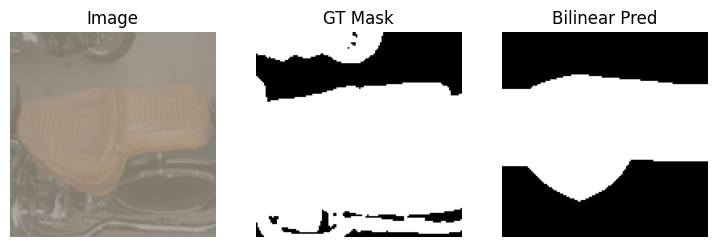

In [33]:
def unnormalize(img_tensor):
    img = img_tensor.clone().permute(1,2,0).numpy()
    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])
    img = img * std + mean
    img = np.clip(img, 0, 1)
    return img

def visualize_samples(model, dataset, n_samples=3, title="Model"):
    model.eval()
    idxs = np.random.choice(len(dataset), size=min(n_samples, len(dataset)), replace=False)

    for idx in idxs:
        img, mask = dataset[idx]
        with torch.no_grad():
            logits = model(img.unsqueeze(0).to(device))
            pred = torch.argmax(logits, dim=1).squeeze(0).cpu().numpy()

        img_np = unnormalize(img)

        plt.figure(figsize=(9,3))
        plt.subplot(1,3,1)
        plt.imshow(img_np); plt.title("Image"); plt.axis("off")

        plt.subplot(1,3,2)
        plt.imshow(mask.numpy(), cmap="gray"); plt.title("GT Mask"); plt.axis("off")

        plt.subplot(1,3,3)
        plt.imshow(pred, cmap="gray"); plt.title(f"{title} Pred"); plt.axis("off")

        plt.show()

print("FCN_Transpose predictions:")
visualize_samples(model_transpose, val_ds, n_samples=3, title="Transpose")
print("-"*100)
print("FCN_Bilinear predictions:")
visualize_samples(model_bilinear, val_ds, n_samples=3, title="Bilinear")

In [32]:
compare_df = pd.DataFrame({"Model": ["FCN_Transpose", "FCN_Bilinear"],"Val Pixel Acc": [hist_transpose["val_acc"][-1],
                      hist_bilinear["val_acc"][-1]],"Val mIoU": [hist_transpose["val_miou"][-1],hist_bilinear["val_miou"][-1]]})
compare_df

,Model,Val Pixel Acc,Val mIoU
0,FCN_Transpose,0.812941,0.625809
1,FCN_Bilinear,0.836906,0.656950


| Model | Pixel Accuracy | Mean IoU | Observation |
|:------|:---------------:|:--------:|:-------------|
| FCN-Transpose | 0.81 | 0.63 | Fine details but checkerboard artifacts |
| FCN-Bilinear | **0.84** | **0.66** | Smoother, better generalization |

## **Conclusion:**  
The experiment compared FCN-Transpose and FCN-Bilinear for semantic segmentation.
Both models converged well, but FCN-Bilinear achieved slightly higher performance with
Pixel Accuracy ≈ 0.84 and mIoU ≈ 0.66, outperforming FCN-Transpose (≈ 0.81 / 0.63).

Visually, the Bilinear model produced smoother and more stable masks,
while Transpose created sharper but noisier boundaries.
Bilinear interpolation helped avoid checkerboard artifacts and yielded cleaner segmentation.

In summary, FCN-Bilinear provided a better trade-off between accuracy and visual quality,
making it more suitable for general segmentation tasks.
